## Pergerakan Saham

In [ ]:
# !pip install yfinance
# !pip install pandas-datareader
import numpy as np
import scipy.stats as ss
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
from pandas_datareader import data as pdr

In [ ]:
tlkm = yf.Ticker("TLKM.JK")
# get historical market data
hist = tlkm.history(start="2024-5-01", end="2025-11-30")
hist.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 379 entries, 2024-05-02 00:00:00+07:00 to 2025-11-28 00:00:00+07:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          379 non-null    float64
 1   High          379 non-null    float64
 2   Low           379 non-null    float64
 3   Close         379 non-null    float64
 4   Volume        379 non-null    int64  
 5   Dividends     379 non-null    float64
 6   Stock Splits  379 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 23.7 KB


In [ ]:
hist['Close']

,Close
Date,
2024-05-02 00:00:00+07:00,2725.662109
2024-05-03 00:00:00+07:00,2760.606445
2024-05-06 00:00:00+07:00,2664.509277
2024-05-07 00:00:00+07:00,2699.453857
2024-05-08 00:00:00+07:00,2690.717773
...,...
2025-11-24 00:00:00+07:00,3700.000000
2025-11-25 00:00:00+07:00,3650.000000
2025-11-26 00:00:00+07:00,3720.000000


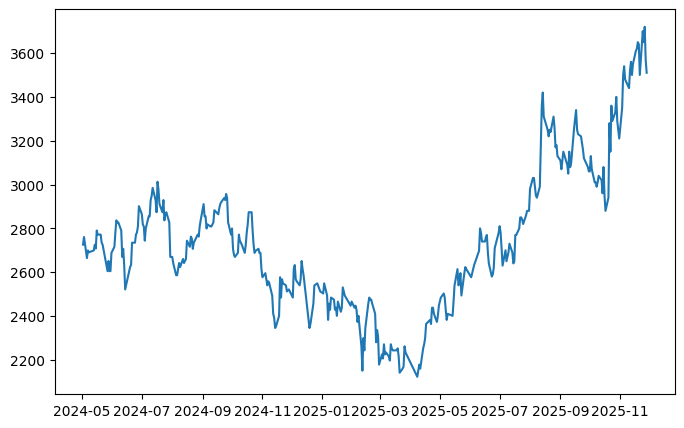

In [ ]:
fig,ax = plt.subplots(1, figsize=(8,5))
ax.plot(hist['Close'])

/tmp/ipython-input-1092293201.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hist['return'] = [hist.Close[i]/hist.Close[i-1] for i in range(1,len(hist))]+[0]


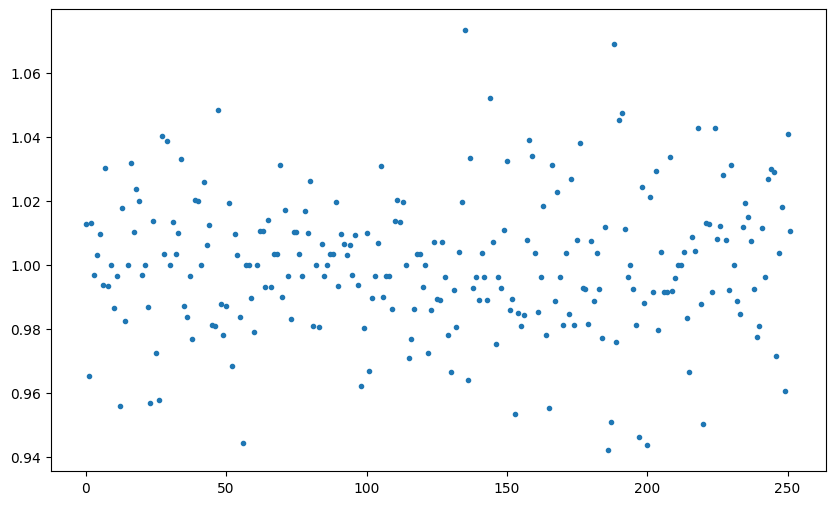

/tmp/ipython-input-1092293201.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  logS= np.log(np.array([hist.Close[i] for i in range(0,int(len(hist)/2))]))


mean, std up 1.0180143842180394 0.014219889118158609
mean, std down 0.9847885533527356 0.013784316022944118
u,d,p= 1.0180143842180394 0.9847885533527356 0.4603174603174603
variansi log saham($sigma^2t$)= 0.06385049298681328


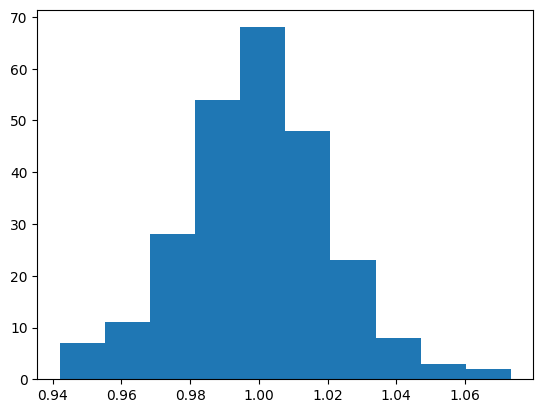

In [ ]:
# estimasi parameter metode empiris
hist['return'] = [hist.Close[i]/hist.Close[i-1] for i in range(1,len(hist))]+[0]
ret = np.array(hist['return'][0:int(len(hist)*2/3)])
fig,ax = plt.subplots(1,figsize=(10,6))
ax.plot(ret,".")
plt.show()
print('mean, std up', np.mean(ret[ret>1]), np.std(ret[ret>1]))
print('mean, std down',np.mean(ret[ret<=1]), np.std(ret[ret<=1]))
plt.hist(ret, bins=10)
up= np.mean(ret[ret>1]) # estimasi nilai u empiris
dwn = np.mean(ret[ret<=1])# estimasi nilai d emspiris
p_empi = len(ret[ret>1])/len(ret)
avret = np.mean(ret)
print('u,d,p=', up,dwn,p_empi)
# sigm=(ret-avret)**2

# estimasi Model CRR sigma
logS= np.log(np.array([hist.Close[i] for i in range(0,int(len(hist)/2))]))
print('variansi log saham($sigma^2t$)=', np.std(logS))
sig = np.sqrt(np.std(logS)/1)# volatilitas harga saham

In [ ]:
import math
# Estimasi nilai sigma dari log(S)
hist['logs'] = np.log(hist["Close"])
logs = np.array(hist['logs'])[0:int(len(hist)*2/3)+1]
varLogs=np.std(logs)**2 #\sigma^2t
sigEst= np.sqrt(varLogs/1)
print(len(hist['logs'][int(len(hist)/2)+1:-1]))

188


/tmp/ipython-input-594178025.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  So = hist.Close[int(len(hist)/2)]


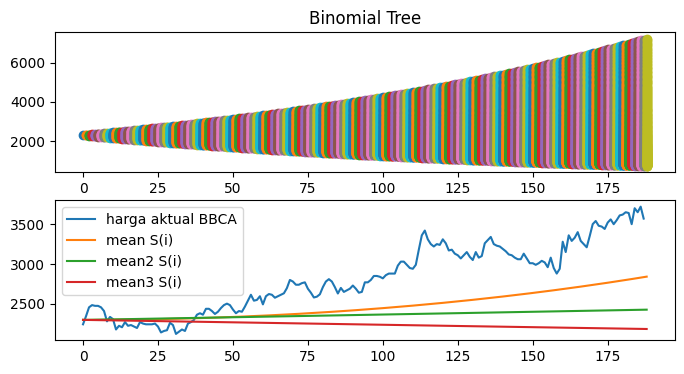

In [ ]:
# Membuat pohon Binomial Saham
So = hist.Close[int(len(hist)/2)]
sig = sigEst
r = 0.0475 # suku bunga bank Indonesia
N = 188 # harian dalam satu tahun
dt = 1/N
u=np.exp(sig*np.sqrt(dt))
d=1/u
p=(np.exp(-r*dt)-d)/(u-d)

fig,ax = plt.subplots(2,figsize=(8,4))
price = np.zeros((N+1,N+1), float)
mean_si = np.zeros((N+1), float)
mean2_si = np.zeros((N+1), float)
mean3_si = np.zeros((N+1), float)
mean_si[0] = So
mean2_si[0] = So
mean3_si[0] = So
price[0,0] = So//1
ax[0].scatter(0, price[0,0])
ax[1].plot(range(len(hist.Close[int(len(hist)/2)+1:-1])), hist.Close[int(len(hist)/2)+1:-1], label='harga aktual BBCA')
for i in range(1,N+1): # time step
  for j in reversed(range(i+1)): # jumlah kenaikan
    price[j,i] = So*u**(j)*d**(i-j)//1
  ax[0].scatter([i for k in range(len(price[0:i+1,i]))], price[0:i+1,i])
  mean_si[i] = np.mean(price[0:i+1,i])
  prob = np.array([math.comb(i, i-k)*p**(i-k)*(1-p)**k for k in range(i+1)])
  # print(prob.shape,price[0:i+1,i].shape )
  mean2_si[i] = np.sum(price[0:i+1,i]*prob) # ekspektasi
  mean3_si[i] = So*u**(i*p)*d**(i-i*p)
    # print(price[j,i])
    # print(j)
ax[0].set_title("Binomial Tree")
ax[1].plot(mean_si, label='mean S(i)')
ax[1].plot(mean2_si, label='mean2 S(i)')
ax[1].plot(mean3_si, label='mean3 S(i)')
plt.legend()

In [ ]:
for i in price:
  print(i)

[2298. 2238. 2180. 2123. 2068. 2014. 1961. 1910. 1860. 1812. 1765.]
[   0. 2360. 2298. 2238. 2180. 2123. 2068. 2014. 1961. 1910. 1860.]
[   0.    0. 2423. 2360. 2298. 2238. 2180. 2123. 2068. 2014. 1961.]
[   0.    0.    0. 2488. 2423. 2360. 2298. 2238. 2180. 2123. 2068.]
[   0.    0.    0.    0. 2555. 2488. 2423. 2360. 2298. 2238. 2180.]
[   0.    0.    0.    0.    0. 2623. 2555. 2488. 2423. 2360. 2298.]
[   0.    0.    0.    0.    0.    0. 2693. 2623. 2555. 2488. 2423.]
[   0.    0.    0.    0.    0.    0.    0. 2766. 2693. 2623. 2555.]
[   0.    0.    0.    0.    0.    0.    0.    0. 2840. 2766. 2693.]
[   0.    0.    0.    0.    0.    0.    0.    0.    0. 2916. 2840.]
[   0.    0.    0.    0.    0.    0.    0.    0.    0.    0. 2994.]


## Monte Carlo Simulation in Financial Stock Model

### Binomial Model for Stock Price
Suppose that discrete time step for a time interval $[0,T]$ is $\{t_0=0, t_1, t_2, \cdots, t_N=T\}$, where $|t_{i+1}-t_{i}|$ are equidistance for all $i$, that is $\Delta t = \frac{T}{N}$.
Assume that for every time step, stock price can only go up with probability $p$ or down with probability $1-p$. And it has fixed factors for going up or down, respectively are $u$ and $d$.

If at $t_0$, the stock price is $S_0$, then at $t_N$ the stock price will be following the binomial distribution, $x~Binom(x;N,p)$ with $x$ here is the number of $S_0$ going up during $\{t_0=0, t_1, t_2, \cdots, t_N=T\}$. And stock price $S(t_N)$ is written as:

$S(t_N)=S_N = S_0 u^x d^{N-x}, $ with probability $P(X=x) = \binom{N}{x} p^x (1-p)^{N-x}$

#### WHat are the parameters $p,u,$ and $d$?
$p = \frac{e^{-r\Delta t }-d}{u-d} $

$u = e^{\sigma \sqrt{\Delta t}}$

$d = e^{-\sigma \sqrt{\Delta t}}$

where $r$ is risk free interest rate, and $\sigma$ is the risk of stock return.

### Stock Price Model at a given time step (Bernouli)
After $\Delta t$, $S(t)$ assume to change following Brown Motion

In [ ]:
# Monte carlo simulation per time steps (Bernouli event for every time step)
so=10
T=1
N=10
dt=T/N
r = 0.0475 # suku bunga bank Indonesia
sig = 0.15
u=np.exp(sig*np.sqrt(dt))
d=1/u
p=(np.exp(-r*dt)-d)/(u-d)
M=20
smt = [[]]
for k in range(M):
  s=so
  sv=[s]
  for i in range(N):
    x=np.random.binomial(N,p)
    s=s*u**(x)*d**(1-x)
    sv=sv+[s]
  smt =smt+[sv]

smt=[k for k in smt[1:][:]]

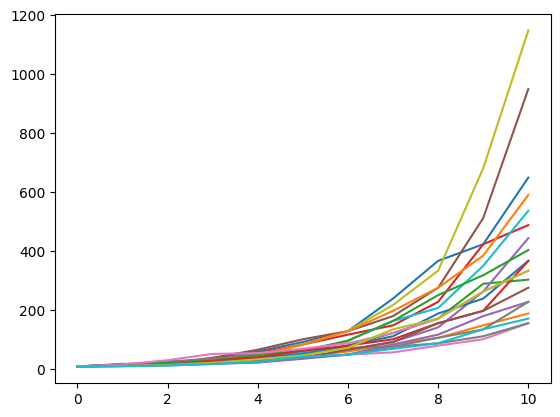

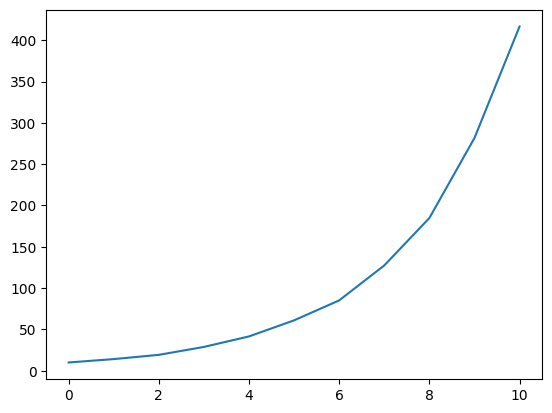

In [ ]:
[plt.plot(k) for k in smt]
plt.show()
## Average path of stock prices
smean=np.mean(np.array(smt), axis=0)
plt.plot(smean)

In [ ]:
# Binomial Tree
so=10
T=1
N=10
dt=T/N
r = 0.06
sig = 0.15
u=np.exp(sig*np.sqrt(dt))
d=1/u
p=(np.exp(-r*dt)-d)/(u-d)
M=20
smt = [[]]
for k in range(M):
  s=so
  sv=[int(s)]
  for i in range(N):
    x=np.random.binomial(N,p)
    s=s*u**(x)*d**(1-x)
    sv=sv+[int(s)]
  smt =smt+[sv]

smt=[k for k in smt[1:][:]]

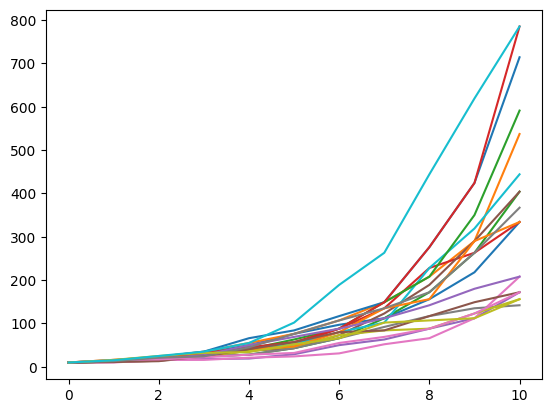

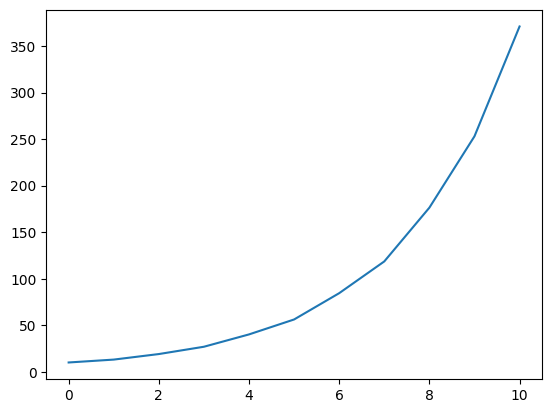

In [ ]:
## MOnte Carlo Simulation
[plt.plot(k) for k in smt]
plt.show()
## Average path of stock prices
smean=np.mean(np.array(smt), axis=0)
plt.plot(smean)